# Part 1

# Command-Line GIS Final Project
By: Habib Gul Ahmadzai

Course: Command-Line GIS (Bloustein School of Planning and Public Policy, Rutgers University, Fall 2025)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install geopandas
!pip install requests
!pip install zipfile
!pip install io
!pip install pandas
!pip install censusdata

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile
ERROR: Could not find a version that satisfies the requirement io (from versions: none)
ERROR: No matching distribution found for io
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for censusdata: filename=CensusData-1.15.post1-py3-none-any.whl size=28205744 sha256=222d0cdf3d4c83e1bbd030749a58f32d0afcc815da21de55a81913372165135f
  Stored in directory: /root/.cache/pip/wheels/54/5e/eb/518ccd7738e6b9b35d9fb3d226d45979066ec367ed26ad1369
Successfully built censusdata


In [ ]:
import geopandas as gpd
import requests, zipfile, io
import pandas as pd
import censusdata
import matplotlib.pyplot as plt
import mapclassify



In [ ]:
# Load ALL US counties (TIGER 2023)
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)

# DMV counties only
dmv_fips = ["11001", "24031", "24033", "51059", "51013"]
counties = counties[counties["GEOID"].isin(dmv_fips)]

counties[["GEOID", "NAME"]]


,GEOID,NAME
630,11001,District of Columbia
1357,24033,Prince George's
1477,24031,Montgomery
1479,51013,Arlington
2856,51059,Fairfax


In [ ]:
def download_tiger_tracts(state_fips):
    url = f"https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_{state_fips}_tract.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(f"tract_{state_fips}")
    gdf = gpd.read_file(f"tract_{state_fips}/tl_2023_{state_fips}_tract.shp")
    return gdf


In [ ]:
dc = download_tiger_tracts("11")       # District of Columbia
maryland = download_tiger_tracts("24") # Maryland (includes Montgomery & PG)
virginia = download_tiger_tracts("51") # Virginia (includes Fairfax & Arlington)


In [ ]:
target_counties = ["11001", "24031", "24033", "51059", "51013"]

# Combine the states
tracts = pd.concat([dc, maryland, virginia], ignore_index=True)

# Keep only tracts where GEOID starts with the target county code
tracts = tracts[tracts["GEOID"].str[:5].isin(target_counties)]

# Keep only the GEOID and geometry (ACS will merge on this)
tracts = tracts[["GEOID", "geometry"]]


In [ ]:
tracts.head()
tracts.shape


(997, 2)

# Part 2

In [ ]:
!pip install censusdata

import censusdata
import pandas as pd


In [ ]:
acs_vars = {
    "B25064_001E": "med_rent",
    "B25064_001M": "med_rent_moe",
    "B19013_001E": "med_income",
    "B19013_001M": "med_income_moe",
    "B08303_001E": "total_commuters",
    "B08303_002E": "t_0_4",
    "B08303_003E": "t_5_9",
    "B08303_004E": "t_10_14",
    "B08303_005E": "t_15_19",
    "B08303_006E": "t_20_24",
    "B08303_007E": "t_25_29",
    "B08303_008E": "t_30_34",
    "B08303_009E": "t_35_44",
    "B08303_010E": "t_45_59",
    "B08303_011E": "t_60_plus",
}


In [ ]:
def load_acs_tracts(state_fips, county_fips, var_dict):
    raw_vars = list(var_dict.keys())
    print("Requesting ACS variables:", raw_vars)

    # Download ACS data
    data = censusdata.download(
        'acs5', 2022,
        censusdata.censusgeo([
            ('state', state_fips),
            ('county', county_fips),
            ('tract', '*')
        ]),
        raw_vars
    )

    # Prepare GEOID
    data = data.reset_index()
    data["GEOID"] = data["index"].apply(
        lambda x: x.geo[0][1] + x.geo[1][1] + x.geo[2][1]
    )

    # Rename columns to readable names
    data = data.rename(columns=var_dict)

    # Return only useful columns
    return data[["GEOID"] + list(var_dict.values())]

In [ ]:
dc_df      = load_acs_tracts("11","001",acs_vars)
mont_df    = load_acs_tracts("24","031",acs_vars)
pg_df      = load_acs_tracts("24","033",acs_vars)
fairfax_df = load_acs_tracts("51","059",acs_vars)
arling_df  = load_acs_tracts("51","013",acs_vars)

# Combine into one dataframe
acs = pd.concat([dc_df, mont_df, pg_df, fairfax_df, arling_df], ignore_index=True)


Requesting ACS variables: ['B25064_001E', 'B25064_001M', 'B19013_001E', 'B19013_001M', 'B08303_001E', 'B08303_002E', 'B08303_003E', 'B08303_004E', 'B08303_005E', 'B08303_006E', 'B08303_007E', 'B08303_008E', 'B08303_009E', 'B08303_010E', 'B08303_011E']
Requesting ACS variables: ['B25064_001E', 'B25064_001M', 'B19013_001E', 'B19013_001M', 'B08303_001E', 'B08303_002E', 'B08303_003E', 'B08303_004E', 'B08303_005E', 'B08303_006E', 'B08303_007E', 'B08303_008E', 'B08303_009E', 'B08303_010E', 'B08303_011E']
Requesting ACS variables: ['B25064_001E', 'B25064_001M', 'B19013_001E', 'B19013_001M', 'B08303_001E', 'B08303_002E', 'B08303_003E', 'B08303_004E', 'B08303_005E', 'B08303_006E', 'B08303_007E', 'B08303_008E', 'B08303_009E', 'B08303_010E', 'B08303_011E']
Requesting ACS variables: ['B25064_001E', 'B25064_001M', 'B19013_001E', 'B19013_001M', 'B08303_001E', 'B08303_002E', 'B08303_003E', 'B08303_004E', 'B08303_005E', 'B08303_006E', 'B08303_007E', 'B08303_008E', 'B08303_009E', 'B08303_010E', 'B08303

In [ ]:
suppression_codes = [-666666666, -333333333, -222222222]

for col in acs.columns:
    if col != "GEOID":
        acs[col] = acs[col].replace(suppression_codes, pd.NA)

In [ ]:
# Convert everything except GEOID to numeric
numeric_cols = [col for col in acs.columns if col != "GEOID"]
acs[numeric_cols] = acs[numeric_cols].apply(pd.to_numeric, errors="coerce")


In [ ]:
# STEP 2.5 — Compute Mean Commute from Commuter Bins
midpoints = {
    "t_0_4": 2.5,
    "t_5_9": 7.5,
    "t_10_14": 12.5,
    "t_15_19": 17.5,
    "t_20_24": 22.5,
    "t_25_29": 27.5,
    "t_30_34": 32.5,
    "t_35_44": 40,
    "t_45_59": 52.5,
    "t_60_plus": 75,
}

def compute_mean_commute(row):
    total = row["total_commuters"]
    if pd.isna(total) or total == 0:
        return pd.NA

    weighted_sum = 0
    for col, midpoint in midpoints.items():
        count = row[col]
        if pd.notna(count):
            weighted_sum += count * midpoint

    return weighted_sum / total


In [ ]:
# Add new column
acs["mean_commute"] = acs.apply(compute_mean_commute, axis=1)


In [ ]:
print("\nFinal Mean Commute Summary:")
print(acs["mean_commute"].describe())
acs.head()


Final Mean Commute Summary:
count     992.000000
unique    992.000000
top        27.975329
freq        1.000000
Name: mean_commute, dtype: float64


,GEOID,med_rent,med_rent_moe,med_income,med_income_moe,total_commuters,t_0_4,t_5_9,t_10_14,t_15_19,t_20_24,t_25_29,t_30_34,t_35_44,t_45_59,t_60_plus,mean_commute
0,11001000101,2760.0,353.0,168705.0,60589.0,459,0,12,142,61,89,54,56,10,0,35,24.542484
1,11001000102,3501.0,NaN,178790.0,50652.0,1121,29,50,140,233,249,43,230,13,57,53,24.99777
2,11001000201,NaN,NaN,NaN,NaN,561,112,187,100,45,33,5,27,5,22,14,14.050802
3,11001000202,3119.0,1144.0,170500.0,79962.0,1543,86,208,218,271,84,44,137,133,117,172,26.673688
4,11001000300,2184.0,342.0,176181.0,49502.0,2491,123,43,235,383,284,206,560,216,44,305,29.847451


# Partb 3


In [ ]:
tracts["GEOID"] = tracts["GEOID"].astype(str)

In [ ]:
acs["GEOID"] = acs["GEOID"].astype(str)

In [ ]:
gdf = tracts.merge(acs, on="GEOID", how="left")

print("Merged dataset shape:", gdf.shape)
gdf.head()

Merged dataset shape: (997, 18)


,GEOID,geometry,med_rent,med_rent_moe,med_income,med_income_moe,total_commuters,t_0_4,t_5_9,t_10_14,t_15_19,t_20_24,t_25_29,t_30_34,t_35_44,t_45_59,t_60_plus,mean_commute
0,11001005302,"POLYGON ((-77.04167 38.91153, -77.04135 38.911...",2436.0,440.0,119769.0,27516.0,1215,0,35,105,121,331,131,263,67,27,70,26.86214
1,11001004402,"POLYGON ((-77.03195 38.91629, -77.03195 38.916...",3017.0,750.0,171017.0,35621.0,1151,0,65,104,84,281,180,229,59,65,68,28.536056
2,11001010602,"POLYGON ((-77.00443 38.90252, -77.00415 38.903...",2836.0,195.0,170670.0,15418.0,2761,44,60,194,391,652,183,549,135,37,231,26.091996
3,11001000804,"POLYGON ((-77.10517 38.91725, -77.10516 38.917...",1898.0,363.0,244375.0,80142.0,1079,16,24,115,337,151,172,123,20,34,32,22.859129
4,11001003902,"POLYGON ((-77.0498 38.92788, -77.04967 38.9280...",2163.0,358.0,111311.0,15768.0,684,0,0,70,134,42,61,56,110,65,73,30.628655


In [ ]:
gdf["med_rent"] = pd.to_numeric(gdf["med_rent"], errors="coerce")
gdf["med_rent_moe"] = pd.to_numeric(gdf["med_rent_moe"], errors="coerce")
gdf["med_income"] = pd.to_numeric(gdf["med_income"], errors="coerce")
gdf["med_income_moe"] = pd.to_numeric(gdf["med_income_moe"], errors="coerce")

In [ ]:
# --------------------------------------------------------
#  FIX 1 — Compute Coefficient of Variation for ACS fields
#  (must run AFTER merging ACS with tract geometry)
# --------------------------------------------------------

import numpy as np

# CV = (MOE / 1.645) / estimate * 100
gdf["rent_cv"] = ((gdf["med_rent_moe"] / 1.645) / gdf["med_rent"]) * 100
gdf["income_cv"] = ((gdf["med_income_moe"] / 1.645) / gdf["med_income"]) * 100

# Handle divide-by-zero and invalid values
gdf["rent_cv"].replace([np.inf, -np.inf], np.nan, inplace=True)
gdf["income_cv"].replace([np.inf, -np.inf], np.nan, inplace=True)

print("CV columns created:")
display(gdf[["rent_cv", "income_cv"]].describe())


CV columns created:


/tmp/ipython-input-1483980555.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf["rent_cv"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-1483980555.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,rent_cv,income_cv
count,886.000000,938.000000
mean,9.233284,12.872868
std,8.748943,7.400506
min,0.914668,1.679272
25%,3.932319,8.225276
50%,6.229224,11.170211
75%,10.581251,15.761691
max,57.842444,57.285545


In [ ]:
import pandas as pd
import urllib.request
import gzip

# ----------------------------------------------
# 4.1 Function to download LODES WAC data
# ----------------------------------------------
def load_lodes_wac(state, year=2020):
    url = f"https://lehd.ces.census.gov/data/lodes/LODES8/{state}/wac/{state}_wac_S000_JT00_{year}.csv.gz"
    print("Downloading:", url)

    df = pd.read_csv(url, compression="gzip", dtype=str)
    df = df.astype({"C000": float})

    # Extract 11-digit census tract from w_geocode (first 11 digits)
    df["GEOID"] = df["w_geocode"].str[:11]

    # Rename total jobs column
    df = df[["GEOID", "C000"]].rename(columns={"C000": "jobs_total"})

    return df

# ----------------------------------------------
# 4.2 Load jobs for DC–MD–VA
# ----------------------------------------------
dc_wac = load_lodes_wac("dc", 2020)
md_wac = load_lodes_wac("md", 2020)
va_wac = load_lodes_wac("va", 2020)

print("DC WAC shape:", dc_wac.shape)
print("MD WAC shape:", md_wac.shape)
print("VA WAC shape:", va_wac.shape)

# ----------------------------------------------
# 4.3 Combine all jobs
# ----------------------------------------------
jobs_all = pd.concat([dc_wac, md_wac, va_wac], ignore_index=True)

# Drop duplicate tracts if they exist
jobs_all = jobs_all.groupby("GEOID", as_index=False).max()

print(jobs_all.head())


Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/dc/wac/dc_wac_S000_JT00_2020.csv.gz
Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/md/wac/md_wac_S000_JT00_2020.csv.gz
Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/va/wac/va_wac_S000_JT00_2020.csv.gz
DC WAC shape: (3729, 2)
MD WAC shape: (29162, 2)
VA WAC shape: (47992, 2)
         GEOID  jobs_total
0  11001000101        99.0
1  11001000102      1674.0
2  11001000201      5004.0
3  11001000202      1064.0
4  11001000300       233.0


In [ ]:
# Merge jobs into gdf
gdf = gdf.merge(jobs_all, on="GEOID", how="left")

# Check merge success
print(gdf[["GEOID", "jobs_total"]].head())
print("Missing jobs:", gdf["jobs_total"].isna().sum())


         GEOID  jobs_total
0  11001005302       321.0
1  11001004402       281.0
2  11001010602       438.0
3  11001000804       259.0
4  11001003902       188.0
Missing jobs: 0


In [ ]:
gdf[["med_rent", "med_rent_moe", "rent_cv"]].sample(10)


,med_rent,med_rent_moe,rent_cv
551,1659.0,116.0,4.250556
265,1534.0,198.0,7.846463
149,1417.0,223.0,9.566853
108,1318.0,69.0,3.182495
605,1578.0,185.0,7.126870
619,1704.0,204.0,7.277709
996,NaN,NaN,NaN
369,2414.0,349.0,8.788652
221,2972.0,1741.0,35.610991
668,2439.0,108.0,2.691820


In [ ]:
print(gdf.shape)
gdf.head()
gdf.isna().sum()


(997, 21)


,0
GEOID,0
geometry,0
med_rent,56
med_rent_moe,111
med_income,11
med_income_moe,59
total_commuters,0
t_0_4,0
t_5_9,0
t_10_14,0


In [ ]:
# Convert to Web Mercator for mapping
gdf_3857 = gdf.to_crs(epsg=3857)
print("Projection fixed:", gdf_3857.crs)


Projection fixed: EPSG:3857


# Part 4

In [ ]:
import pandas as pd

def load_lodes_wac(state, year=2020, segment="S000", job_type="JT00", version="LODES8"):
    """
    Download Workplace Area Characteristics (WAC) data from LODES8.

    state   = 'dc', 'md', or 'va'
    year    = 2002–2020 (we'll use 2020)
    segment = 'S000' (all workers)
    job_type= 'JT00' (all jobs)
    """
    base = f"https://lehd.ces.census.gov/data/lodes/{version}/{state}/wac"
    filename = f"{state}_wac_{segment}_{job_type}_{year}.csv.gz"
    url = f"{base}/{filename}"
    print("Downloading:", url)

    wac = pd.read_csv(url, dtype={"w_geocode": str})
    return wac


In [ ]:
# DC, Maryland, Virginia – all using 2020 WAC
dc_wac = load_lodes_wac("dc", 2020)
md_wac = load_lodes_wac("md", 2020)
va_wac = load_lodes_wac("va", 2020)

# Quick sanity check
print("DC WAC shape:", dc_wac.shape)
print("MD WAC shape:", md_wac.shape)
print("VA WAC shape:", va_wac.shape)

dc_wac.head()


Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/dc/wac/dc_wac_S000_JT00_2020.csv.gz
Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/md/wac/md_wac_S000_JT00_2020.csv.gz
Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/va/wac/va_wac_S000_JT00_2020.csv.gz
DC WAC shape: (3729, 53)
MD WAC shape: (29162, 53)
VA WAC shape: (47992, 53)


,w_geocode,C000,CA01,CA02,CA03,CE01,CE02,CE03,CNS01,CNS02,...,CFA02,CFA03,CFA04,CFA05,CFS01,CFS02,CFS03,CFS04,CFS05,createdate
0,110010001011000,46,6,28,12,7,5,34,0,0,...,0,0,0,0,0,0,0,0,0,20230321
1,110010001011003,61,10,32,19,20,13,28,0,0,...,0,0,0,0,0,0,0,0,0,20230321
2,110010001011004,32,5,20,7,3,6,23,0,0,...,0,0,0,0,0,0,0,0,0,20230321
3,110010001011005,7,0,1,6,1,3,3,0,0,...,0,0,0,0,0,0,0,0,0,20230321
4,110010001011006,11,1,6,4,3,7,1,0,0,...,0,0,0,0,0,0,0,0,0,20230321


In [ ]:
def wac_to_tract_jobs(wac_df):
    # 11-digit tract GEOID from 15-digit workplace block geocode
    wac_df["GEOID"] = wac_df["w_geocode"].str.slice(0, 11)

    # Aggregate total jobs C000 by tract
    jobs = (
        wac_df
        .groupby("GEOID", as_index=False)["C000"]
        .sum()
        .rename(columns={"C000": "jobs_total"})
    )
    return jobs

dc_jobs  = wac_to_tract_jobs(dc_wac)
md_jobs  = wac_to_tract_jobs(md_wac)
va_jobs  = wac_to_tract_jobs(va_wac)

jobs_all = pd.concat([dc_jobs, md_jobs, va_jobs], ignore_index=True)

print("DC jobs:", dc_jobs.shape)
print("MD jobs:", md_jobs.shape)
print("VA jobs:", va_jobs.shape)
print("All jobs:", jobs_all.shape)

jobs_all.head()


DC jobs: (206, 2)
MD jobs: (1461, 2)
VA jobs: (2182, 2)
All jobs: (3849, 2)


,GEOID,jobs_total
0,11001000101,284
1,11001000102,8797
2,11001000201,5278
3,11001000202,5241
4,11001000300,718


In [ ]:
# gdf already has GEOID + geometry + ACS (from Parts 1–3) and jobs_total from cell 75tnQKrBEJ3O
print("gdf columns before merge:", gdf.columns)

# The merge operation is redundant as it was already performed in cell 75tnQKrBEJ3O.
# Removing this line to prevent column renaming issues.
# gdf = gdf.merge(jobs_all, on="GEOID", how="left")

print("gdf shape after (initial) adding jobs:", gdf.shape)
print(gdf[["GEOID", "med_rent", "med_income", "mean_commute", "jobs_total"]].head())

In [ ]:
!pip install contextily


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify

# Project to Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)
counties_3857 = counties.to_crs(epsg=3857)

# County label points
counties_3857["centroid"] = counties_3857.geometry.centroid


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np

# Ensure Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

# ADD THIS ⬇️
counties_3857 = counties.to_crs(epsg=3857)
counties_3857["centroid"] = counties_3857.geometry.centroid

# Drop NA for classification
rent_valid = gdf_3857["med_rent"].dropna()

# Classify into 5 quantiles
classifier = mapclassify.Quantiles(rent_valid, k=5)
bins = classifier.bins

# Colors for bins
cmap = plt.cm.get_cmap("Purples", 5)
bin_colors = [cmap(i) for i in range(5)]

fig, ax = plt.subplots(figsize=(12, 12))

# --- Base rent map (thin tract lines) ---
gdf_3857.plot(
    ax=ax,
    column="med_rent",
    cmap="Purples",
    scheme="Quantiles",
    k=5,
    linewidth=0.2,          # thin tract boundaries
    edgecolor="black"
)

# --- No Data ---
gdf_3857[gdf_3857["med_rent"].isna()].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# --- Hatched High CV ---
gdf_3857[gdf_3857["rent_cv"] >= 40].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    hatch="///",
    linewidth=0.4
)

# ===============================
# ADD THIS: COUNTY BOUNDARIES
# ===============================
counties_3857.boundary.plot(
    ax=ax,
    linewidth=3,            # thick county boundaries
    color="black"
)

# ===============================
# ADD THIS: COUNTY LABELS
# ===============================
import matplotlib.patheffects as pe

for _, row in counties_3857.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        row["NAME"],
        fontsize=12,
        fontweight="bold",
        color="black",
        ha="center",
        va="center",
        path_effects=[
            pe.withStroke(linewidth=3.5, foreground="white")
        ]
    )


# --- Add basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)
ax.axis("off")

# --- Title ---
ax.set_title(
    "Median Gross Rent by Census Tract (ACS 2022)\nHatched Tracts = CV ≥ 40%",
    fontsize=16
)

# -------------------------------
#    CUSTOM LEGEND CONSTRUCTION
# -------------------------------
legend_elements = []

for i, upper in enumerate(bins):
    lower = rent_valid.min() if i == 0 else bins[i-1]
    label = f"{lower:,.2f} – {upper:,.2f}"
    patch = Patch(facecolor=bin_colors[i], edgecolor="black", label=label)
    legend_elements.append(patch)

legend_elements.append(
    Patch(facecolor="lightgray", edgecolor="black", label="No Data")
)

legend_elements.append(
    Patch(facecolor="white", edgecolor="black", hatch="///", label="CV ≥ 40%")
)

ax.legend(
    handles=legend_elements,
    title="Median Gross Rent ($)",
    loc="lower left",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

fig.savefig("median_rent_cv_map.png", dpi=300, bbox_inches="tight")


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

# Ensure Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

# Counties (already loaded earlier)
counties_3857 = counties.to_crs(epsg=3857)
counties_3857["centroid"] = counties_3857.geometry.centroid

# Valid commute values
commute_valid = gdf_3857["mean_commute"].dropna()

# Quantile classification
classifier = mapclassify.Quantiles(commute_valid, k=5)
bins = classifier.bins

# SAME colormap as rent
cmap = plt.cm.get_cmap("Purples", 5)
bin_colors = [cmap(i) for i in range(5)]

fig, ax = plt.subplots(figsize=(12, 12))

# --- Base commute map (thin tract lines) ---
gdf_3857.plot(
    ax=ax,
    column="mean_commute",
    cmap="Purples",
    scheme="Quantiles",
    k=5,
    linewidth=0.2,          # thin tract boundaries
    edgecolor="black"
)

# --- No Data ---
gdf_3857[gdf_3857["mean_commute"].isna()].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# --- County boundaries (thick) ---
counties_3857.boundary.plot(
    ax=ax,
    linewidth=3,
    color="black"
)

# --- County labels (with halo) ---
for _, row in counties_3857.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        row["NAME"],
        fontsize=12,
        fontweight="bold",
        color="black",
        ha="center",
        va="center",
        path_effects=[
            pe.withStroke(linewidth=3.5, foreground="white")
        ]
    )

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)
ax.axis("off")

# --- Title ---
ax.set_title(
    "Mean Commute Time by Census Tract (ACS 2022)\n(Values in Minutes)",
    fontsize=16
)

# -------------------------------
#   CUSTOM LEGEND (MATCHING RENT)
# -------------------------------
legend_elements = []

for i, upper in enumerate(bins):
    lower = commute_valid.min() if i == 0 else bins[i-1]
    label = f"{lower:.1f} – {upper:.1f} minutes"
    legend_elements.append(
        Patch(facecolor=bin_colors[i], edgecolor="black", label=label)
    )

legend_elements.append(
    Patch(facecolor="lightgray", edgecolor="black", label="No Data")
)

ax.legend(
    handles=legend_elements,
    title="Commute Time (Minutes)",
    loc="lower left",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

fig.savefig("mean_commute_map.png", dpi=300, bbox_inches="tight")


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

# -------------------------------------------------
# PREP
# -------------------------------------------------
gdf_3857 = gdf.to_crs(epsg=3857)
counties_3857 = counties.to_crs(epsg=3857)
counties_3857["centroid"] = counties_3857.geometry.centroid

# Classifiers
rent_valid = gdf_3857["med_rent"].dropna()
rent_bins = mapclassify.Quantiles(rent_valid, k=5).bins

commute_valid = gdf_3857["mean_commute"].dropna()
commute_bins = mapclassify.Quantiles(commute_valid, k=5).bins

# Shared colormap
cmap = plt.cm.get_cmap("Purples", 5)
rent_colors = [cmap(i) for i in range(5)]
commute_colors = [cmap(i) for i in range(5)]

# -------------------------------------------------
# FIGURE
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

# =================================================
# LEFT: MEDIAN RENT
# =================================================
ax = axes[0]

gdf_3857.plot(
    ax=ax,
    column="med_rent",
    cmap="Purples",
    scheme="Quantiles",
    k=5,
    linewidth=0.2,
    edgecolor="black"
)

gdf_3857[gdf_3857["med_rent"].isna()].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

gdf_3857[gdf_3857["rent_cv"] >= 40].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    hatch="///",
    linewidth=0.4
)

counties_3857.boundary.plot(ax=ax, linewidth=3, color="black")

for _, row in counties_3857.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        row["NAME"],
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        path_effects=[pe.withStroke(linewidth=3.5, foreground="white")]
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)
ax.set_title("Median Gross Rent (ACS 2022)", fontsize=15)
ax.axis("off")

# ---- Rent Legend ----
rent_legend = []
for i, upper in enumerate(rent_bins):
    lower = rent_valid.min() if i == 0 else rent_bins[i-1]
    rent_legend.append(
        Patch(facecolor=rent_colors[i], edgecolor="black",
              label=f"${lower:,.0f} – ${upper:,.0f}")
    )

rent_legend.extend([
    Patch(facecolor="lightgray", edgecolor="black", label="No Data"),
    Patch(facecolor="white", edgecolor="black", hatch="///", label="CV ≥ 40%")
])

ax.legend(
    handles=rent_legend,
    title="Median Rent ($)",
    loc="lower left",
    fontsize=9,
    frameon=True
)

# =================================================
# RIGHT: MEAN COMMUTE
# =================================================
ax = axes[1]

gdf_3857.plot(
    ax=ax,
    column="mean_commute",
    cmap="Purples",
    scheme="Quantiles",
    k=5,
    linewidth=0.2,
    edgecolor="black"
)

gdf_3857[gdf_3857["mean_commute"].isna()].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

counties_3857.boundary.plot(ax=ax, linewidth=3, color="black")

for _, row in counties_3857.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        row["NAME"],
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        path_effects=[pe.withStroke(linewidth=3.5, foreground="white")]
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)
ax.set_title("Mean Commute Time (ACS 2022)", fontsize=15)
ax.axis("off")

# ---- Commute Legend ----
commute_legend = []
for i, upper in enumerate(commute_bins):
    lower = commute_valid.min() if i == 0 else commute_bins[i-1]
    commute_legend.append(
        Patch(facecolor=commute_colors[i], edgecolor="black",
              label=f"{lower:.1f} – {upper:.1f} min")
    )

commute_legend.append(
    Patch(facecolor="lightgray", edgecolor="black", label="No Data")
)

ax.legend(
    handles=commute_legend,
    title="Commute Time (Minutes)",
    loc="lower left",
    fontsize=9,
    frameon=True
)

# -------------------------------------------------
plt.tight_layout()
plt.show()

fig.savefig("rent_commute_side_by_side.png", dpi=300, bbox_inches="tight")


/tmp/ipython-input-1136467631.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Purples", 5)


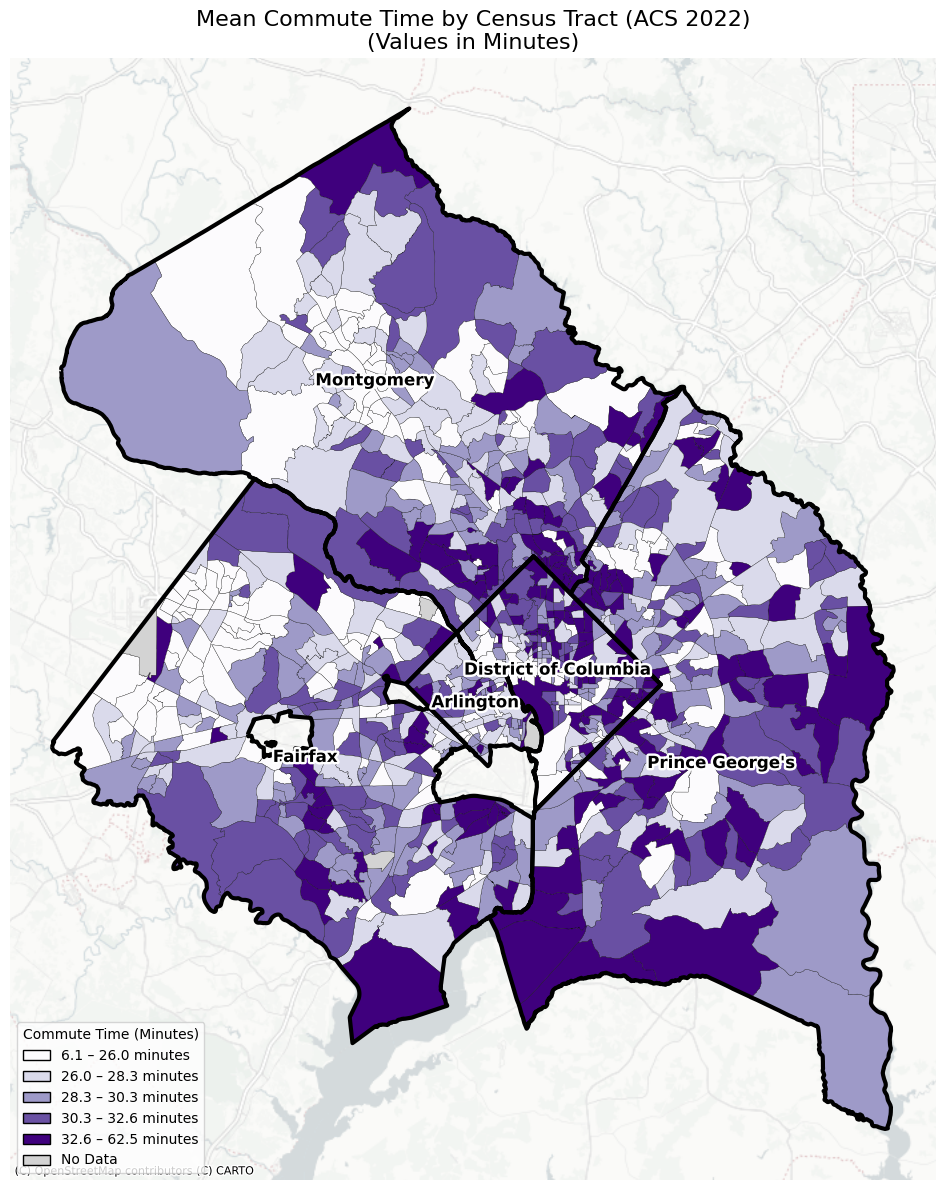

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

# Ensure Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

# Counties (already loaded earlier)
counties_3857 = counties.to_crs(epsg=3857)
counties_3857["centroid"] = counties_3857.geometry.centroid

# Valid commute values
commute_valid = gdf_3857["mean_commute"].dropna()

# Quantile classification
classifier = mapclassify.Quantiles(commute_valid, k=5)
bins = classifier.bins

# COMMUTE colormap (distinct from rent)
cmap = plt.cm.get_cmap("Purples", 5)
bin_colors = [cmap(i) for i in range(5)]

fig, ax = plt.subplots(figsize=(12, 12))

# --- Base commute map (thin tract lines) ---
gdf_3857.plot(
    ax=ax,
    column="mean_commute",
    cmap="Purples",
    scheme="Quantiles",
    k=5,
    linewidth=0.2,
    edgecolor="black"
)

# --- No Data ---
gdf_3857[gdf_3857["mean_commute"].isna()].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# --- County boundaries (thick) ---
counties_3857.boundary.plot(
    ax=ax,
    linewidth=3,
    color="black"
)

# --- County labels (haloed) ---
for _, row in counties_3857.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        row["NAME"],
        fontsize=12,
        fontweight="bold",
        color="black",
        ha="center",
        va="center",
        path_effects=[pe.withStroke(linewidth=3.5, foreground="white")]
    )

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)
ax.axis("off")

# --- Title ---
ax.set_title(
    "Mean Commute Time by Census Tract (ACS 2022)\n(Values in Minutes)",
    fontsize=16
)

# -------------------------------
#   CUSTOM LEGEND
# -------------------------------
legend_elements = []

for i, upper in enumerate(bins):
    lower = commute_valid.min() if i == 0 else bins[i-1]
    label = f"{lower:.1f} – {upper:.1f} minutes"
    legend_elements.append(
        Patch(facecolor=bin_colors[i], edgecolor="black", label=label)
    )

legend_elements.append(
    Patch(facecolor="lightgray", edgecolor="black", label="No Data")
)

ax.legend(
    handles=legend_elements,
    title="Commute Time (Minutes)",
    loc="lower left",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

fig.savefig("mean_commute_map.png", dpi=300, bbox_inches="tight")


In [ ]:
# -------------------------------------------------------------
# FINAL INTERACTIVE MAP — FOLIUM (ERROR-FREE, STABLE)
# -------------------------------------------------------------

import folium
from folium.features import GeoJsonTooltip, GeoJsonPopup
import pandas as pd

# -------------------------------------------------------------------
# 1. Convert to WGS84
# -------------------------------------------------------------------
gdf_wgs84 = gdf.to_crs(epsg=4326).copy()
counties_wgs84 = counties.to_crs(epsg=4326).copy()

# -------------------------------------------------------------------
# 2. Numeric + formatted fields
# -------------------------------------------------------------------
for col in ["med_rent", "med_income", "mean_commute"]:
    gdf_wgs84[col] = pd.to_numeric(gdf_wgs84[col], errors="coerce")

def fmt_dollar(x):
    return f"${x:,.0f}" if pd.notna(x) else "No Data"

def fmt_minutes(x):
    return f"{x:.1f} min" if pd.notna(x) else "No Data"

gdf_wgs84["rent_str"] = gdf_wgs84["med_rent"].apply(fmt_dollar)
gdf_wgs84["income_str"] = gdf_wgs84["med_income"].apply(fmt_dollar)
gdf_wgs84["commute_str"] = gdf_wgs84["mean_commute"].apply(fmt_minutes)

# -------------------------------------------------------------------
# 3. Map center
# -------------------------------------------------------------------
center = gdf_wgs84.geometry.union_all().centroid

m = folium.Map(
    location=[center.y, center.x],
    zoom_start=10,
    tiles="CartoDB Positron"
)

# -------------------------------------------------------------------
# 4. Median Rent Choropleth (DEFAULT ON)
# -------------------------------------------------------------------
folium.Choropleth(
    geo_data=gdf_wgs84,
    data=gdf_wgs84,
    columns=["GEOID", "med_rent"],
    key_on="feature.properties.GEOID",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    name="Median Rent ($)"     # ← this enables toggle
).add_to(m)                    # ← MUST be added to Map

# -------------------------------------------------------------------
# 5. Commute Choropleth (TOGGLE OFF)
# -------------------------------------------------------------------
folium.Choropleth(
    geo_data=gdf_wgs84,
    data=gdf_wgs84,
    columns=["GEOID", "mean_commute"],
    key_on="feature.properties.GEOID",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    name="Mean Commute Time (min)",
    legend_name="Mean Commute Time (min)",
    show=False
).add_to(m)

# -------------------------------------------------------------------
# 6. TOOLTIP + POPUP LAYER (HOVER WORKS EVERYWHERE)
# -------------------------------------------------------------------
tooltip = GeoJsonTooltip(
    fields=["GEOID", "rent_str", "income_str", "commute_str"],
    aliases=["Tract:", "Median Rent:", "Median Income:", "Mean Commute:"],
    sticky=True
)

popup = GeoJsonPopup(
    fields=["GEOID", "rent_str", "income_str", "commute_str"],
    labels=True
)

folium.GeoJson(
    gdf_wgs84,
    tooltip=tooltip,
    popup=popup,
    style_function=lambda f: {
        "fillOpacity": 0.001,   # critical: hoverable, not masking
        "color": "transparent",
        "weight": 0
    },
    name="Tract Info (Hover)"
).add_to(m)

# -------------------------------------------------------------------
# 7. County Boundaries (THICK)
# -------------------------------------------------------------------
folium.GeoJson(
    counties_wgs84,
    style_function=lambda f: {
        "fillOpacity": 0,
        "color": "black",
        "weight": 3
    },
    tooltip=GeoJsonTooltip(
        fields=["NAME"],
        aliases=["County:"]
    ),
    name="County Boundaries"
).add_to(m)

# -------------------------------------------------------------------
# 8. County Labels
# -------------------------------------------------------------------
for _, row in counties_wgs84.iterrows():
    c = row.geometry.centroid
    folium.Marker(
        location=[c.y, c.x],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                text-shadow:
                    -1px -1px 0 white,
                     1px -1px 0 white,
                    -1px  1px 0 white,
                     1px  1px 0 white;">
                {row['NAME']}
            </div>
            """
        )
    ).add_to(m)

# -------------------------------------------------------------------
# 9. Layer Control (TOGGLES WORK)
# -------------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

m


In [ ]:
import folium
from folium.features import GeoJsonTooltip
import pandas as pd

# -------------------------------------------------------------
# DATA PREP
# -------------------------------------------------------------
gdf_wgs84 = gdf.to_crs(epsg=4326).copy()
counties_wgs84 = counties.to_crs(epsg=4326).copy()

for col in ["med_rent", "med_income", "mean_commute"]:
    gdf_wgs84[col] = pd.to_numeric(gdf_wgs84[col], errors="coerce")

gdf_wgs84["rent_str"] = gdf_wgs84["med_rent"].apply(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "No Data"
)
gdf_wgs84["income_str"] = gdf_wgs84["med_income"].apply(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "No Data"
)
gdf_wgs84["commute_str"] = gdf_wgs84["mean_commute"].apply(
    lambda x: f"{x:.1f} min" if pd.notna(x) else "No Data"
)

# -------------------------------------------------------------
# MAP
# -------------------------------------------------------------
center = gdf_wgs84.geometry.centroid
m = folium.Map(
    location=[center.y.mean(), center.x.mean()],
    zoom_start=9,
    tiles="CartoDB Positron"
)

# -------------------------------------------------------------
# RENT CHOROPLETH
# -------------------------------------------------------------
rent = folium.Choropleth(
    geo_data=gdf_wgs84,
    data=gdf_wgs84,
    columns=["GEOID", "med_rent"],
    key_on="feature.properties.GEOID",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    name="Median Rent ($)",
    show=True
).add_to(m)

rent.geojson.add_child(
    GeoJsonTooltip(
        fields=["GEOID", "rent_str", "income_str", "commute_str"],
        aliases=["Tract:", "Median Rent:", "Median Income:", "Mean Commute:"],
        sticky=True
    )
)

# 🔥 THIS IS THE KEY LINE
rent.geojson.control = False

# -------------------------------------------------------------
# COMMUTE CHOROPLETH
# -------------------------------------------------------------
commute = folium.Choropleth(
    geo_data=gdf_wgs84,
    data=gdf_wgs84,
    columns=["GEOID", "mean_commute"],
    key_on="feature.properties.GEOID",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    name="Commute Time (Min)",
    show=False
).add_to(m)

commute.geojson.add_child(
    GeoJsonTooltip(
        fields=["GEOID", "rent_str", "income_str", "commute_str"],
        aliases=["Tract:", "Median Rent:", "Median Income:", "Mean Commute:"],
        sticky=True
    )
)

# 🔥 SAME FIX
commute.geojson.control = False

# -------------------------------------------------------------
# COUNTY BOUNDARIES (NON-INTERACTIVE)
# -------------------------------------------------------------
folium.GeoJson(
    counties_wgs84,
    name="County Boundaries",   # ✅ THIS IS THE KEY LINE
    style_function=lambda f: {
        "fillOpacity": 0,
        "color": "black",
        "weight": 3
    },
    interactive=False
).add_to(m)


# -------------------------------------------------------------
# COUNTY LABELS
# -------------------------------------------------------------
for _, row in counties_wgs84.iterrows():
    c = row.geometry.centroid
    folium.Marker(
        location=[c.y, c.x],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                text-shadow:
                    -1px -1px 0 white,
                     1px -1px 0 white,
                    -1px  1px 0 white,
                     1px  1px 0 white;">
                {row['NAME']}
            </div>
            """
        )
    ).add_to(m)

# -------------------------------------------------------------
# LAYER CONTROL
# -------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

m
m.save("dmv_interactive.html")
